In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Reading the file
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
data = pd.read_csv(io.StringIO(uploaded['US Soybeans Futures Historical Data.csv'].decode('utf-8')))

Saving US Soybeans Futures Historical Data.csv to US Soybeans Futures Historical Data.csv


In [3]:
# Convert "Vol." column to float datatype with suffix conversion
# Converting "Price", "Open", "High", "Low", "Vol." columns to float datatype
data['Price'] = data['Price'].str.replace(',', '').astype(float)
data['Open'] = data['Open'].str.replace(',', '').astype(float)
data['High'] = data['High'].str.replace(',', '').astype(float)
data['Low'] = data['Low'].str.replace(',', '').astype(float)
data['Vol.'] = data['Vol.'].str.replace('K', '').astype(float) * 1000.
print(data.dtypes)

Date         object
Price       float64
Open        float64
High        float64
Low         float64
Vol.        float64
Change %     object
dtype: object


In [4]:
# fill missing values with mean of the column
data = data.fillna(data.mean())

# Check for null values in each column again
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64


<ipython-input-4-4e933ffb9d75>:2: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  data = data.fillna(data.mean())


In [5]:
# Convert the "date" column to a datetime object
data['Date'] = pd.to_datetime(data['Date'])

In [6]:
# Drop a column from the dataset
data = data.drop('Change %', axis=1)

# Show the updated dataset
print(data.head())

        Date    Price     Open     High      Low      Vol.
0 2022-12-25  1524.00  1495.75  1537.50  1485.00  321320.0
1 2022-12-18  1479.00  1470.00  1489.00  1460.00  374100.0
2 2022-12-11  1480.00  1482.12  1487.62  1457.75   69330.0
3 2022-12-04  1483.75  1440.50  1492.75  1435.25  496710.0
4 2022-11-27  1438.50  1428.25  1478.50  1424.00  420750.0


In [7]:
# Feature engineering to join 3 attributes
data['OpenHighLow'] = data['Open'] * data['High']  * data['Low']

In [8]:
# extract features and target
X = data[['Open', 'High', 'Low','Vol.']]
y = data['Price']

In [9]:
# reshape the target variable into a 2D array
y = y.ravel()

In [10]:
"""
from sklearn.model_selection import train_test_split

# Split the data into a 80/20 train/test split
train_X, test_X, train_y, test_y = train_test_split(data, y, test_size=0.2,random_state=42)
"""

'\nfrom sklearn.model_selection import train_test_split\n\n# Split the data into a 80/20 train/test split\ntrain_X, test_X, train_y, test_y = train_test_split(data, y, test_size=0.2,random_state=42)\n'

In [11]:
# Addition
# Select the rows for the training set (2000-2019)
train_X = X[data['Date'].dt.year.between(2000, 2019)]
train_y = y[data['Date'].dt.year.between(2000, 2019)]

# Select the rows for the test set (2020-2022)
test_X = X[data['Date'].dt.year.between(2020, 2022)]
test_y = y[data['Date'].dt.year.between(2020, 2022)]

In [12]:
# Standardising the dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train = scaler.fit_transform(train_X)
test = scaler.transform(test_X)

In [13]:
# Feature selection using SelectKBest and f_regression
from sklearn.feature_selection import SelectKBest, f_regression
selector = SelectKBest(f_regression, k=3)
train_X = selector.fit_transform(train_X, train_y)
test_X = selector.transform(test_X)

In [14]:
from sklearn.svm import SVR
# Create an SVR model
svr = SVR()

In [15]:
# Define hyperparameters for GridSearchCV
parameters = {'kernel': ['linear', 'rbf'], 'C': [1, 10, 100], 'epsilon': [0.1, 0.01, 0.001]}

In [16]:
# Perform hyperparameter tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(svr, parameters, scoring='neg_mean_squared_error')
grid_search.fit(train_X, train_y)

GridSearchCV(estimator=SVR(),
             param_grid={'C': [1, 10, 100], 'epsilon': [0.1, 0.01, 0.001],
                         'kernel': ['linear', 'rbf']},
             scoring='neg_mean_squared_error')

In [17]:
# Get the best SVR model
best_svr = grid_search.best_estimator_

In [18]:
# Fit the model to the training data
#svr.fit(train_X, train_y)

In [19]:
# Make predictions on the training data
#train_pred = svr.predict(train_X)

In [20]:
# Make predictions on the test data
test_pred = best_svr.predict(test_X)

In [21]:
# Calculate R-squared
from sklearn.metrics import r2_score
r2 = r2_score(test_y, test_pred)
print(r2)

# Calculate RMSE for the test set
from sklearn.metrics import mean_squared_error
test_rmse = np.sqrt(mean_squared_error(test_y, test_pred))


print("Root Mean Squared Error (Test):", test_rmse)
print("Best SVR model:", best_svr)
print("Best parameters:", grid_search.best_params_)

0.9936932270428679
Root Mean Squared Error (Test): 21.067766508937808
Best SVR model: SVR(C=1, epsilon=0.001, kernel='linear')
Best parameters: {'C': 1, 'epsilon': 0.001, 'kernel': 'linear'}


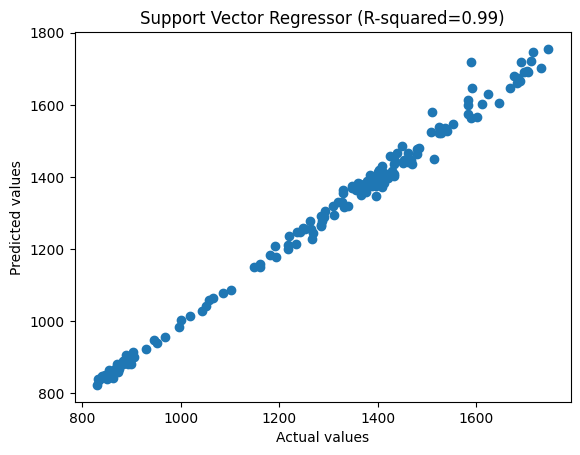

In [22]:
# Plot actual vs predicted values
plt.scatter(test_y, test_pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title(f"Support Vector Regressor (R-squared={r2:.2f})")
plt.show()